<a href="https://colab.research.google.com/github/heidy0099/Proy.Org/blob/main/PROYECTO_3_DERIVADOS_DE_ACIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# CARGAR DATOS - Ejecutar siempre al inicio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]), delimiter=';', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

Saving Proyecto 3 Quimica Organica.csv to Proyecto 3 Quimica Organica (2).csv


In [30]:
# Limpiar datos nulos: reemplaza multiplos formatos de "vacio" por NaN
df = df.replace([0, '0', '0.00', '0,0', 'nan', 'None', '', ';'], np.nan)

def clean_float(x):
    """
    Convierte un valor a float si es posible.
    Retorna NaN si el valor es nulo, cero, o no se puede convertir.
    MODIFICABLE: cambiar 'x > 0' a 'x >= 0' para permitir ceros
    """
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return x if x > 0 else np.nan
    try:
        x_str = str(x).strip().replace(',', '.').replace(';', '')
        val = float(x_str)
        return val if val > 0 else np.nan
    except:
        return np.nan

# MODIFICABLE: Anadir o quitar columnas segun tu archivo
columnas_numericas = [
    'PM_Sustrato', 'PE_Sustrato °C', 'pKa_Sustrato', 'LD50_Sustrato mg /kg',
    'PM_Producto', 'PE_Producto', 'pKa_Producto', 'LD50_Producto Mamifero mg /kg'
]

for col in columnas_numericas:
    if col in df.columns:
        df[col] = df[col].apply(clean_float)

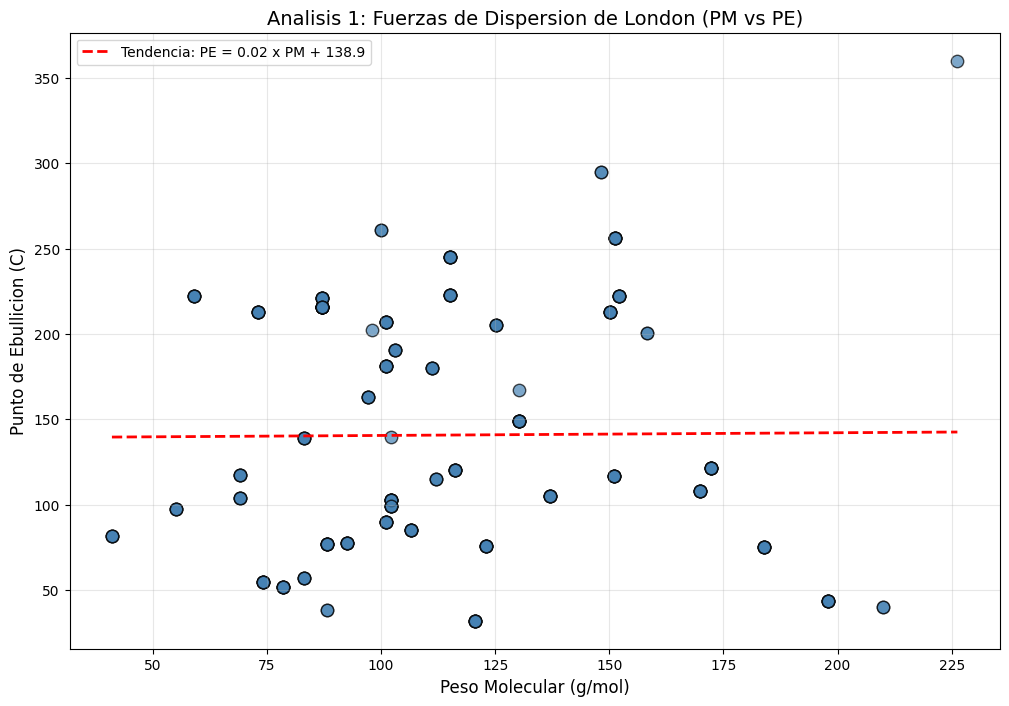

Correlacion de Pearson: r = 0.008
Conclusion: A mayor masa molar, mayor punto de ebullicion por mayor polarizabilidad


In [31]:
# Filtrar datos validos y dentro de rangos razonables
plot_df = df.dropna(subset=['PM_Sustrato', 'PE_Sustrato °C'])

# MODIFICABLE: Rangos de los ejes (PM: 40-300 g/mol, PE: 20-400 °C)
plot_df = plot_df[(plot_df['PM_Sustrato'] >= 40) & (plot_df['PM_Sustrato'] <= 300)]
plot_df = plot_df[(plot_df['PE_Sustrato °C'] >= 20) & (plot_df['PE_Sustrato °C'] <= 400)]

if len(plot_df) >= 3:
    # MODIFICABLE: figsize = (ancho, alto) en pulgadas
    plt.figure(figsize=(12, 8))

    # MODIFICABLE: alpha (transparencia), s (tamano), c (color), edgecolors (borde)
    plt.scatter(plot_df['PM_Sustrato'], plot_df['PE_Sustrato °C'],
                alpha=0.7, s=80, c='steelblue', edgecolors='black')

    # Linea de tendencia (regresion lineal de grado 1)
    z = np.polyfit(plot_df['PM_Sustrato'], plot_df['PE_Sustrato °C'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_df['PM_Sustrato'].min(), plot_df['PM_Sustrato'].max(), 100)

    # MODIFICABLE: color, estilo (--, -, :), grosor de la linea
    plt.plot(x_line, p(x_line), 'r--', linewidth=2,
             label=f'Tendencia: PE = {z[0]:.2f} x PM + {z[1]:.1f}')

    # MODIFICABLE: textos de etiquetas y titulo
    plt.xlabel('Peso Molecular (g/mol)', fontsize=12)
    plt.ylabel('Punto de Ebullicion (C)', fontsize=12)
    plt.title('Analisis 1: Fuerzas de Dispersion de London (PM vs PE)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Calcular correlacion de Pearson
    corr = plot_df['PM_Sustrato'].corr(plot_df['PE_Sustrato °C'])
    print(f"Correlacion de Pearson: r = {corr:.3f}")
    print("Conclusion: A mayor masa molar, mayor punto de ebullicion por mayor polarizabilidad")
else:
    print(f"Datos insuficientes para Analisis 1: {len(plot_df)} compuestos")

/tmp/ipykernel_843/3730720270.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo Funcional', y='PE_Sustrato °C', data=plot_df, palette='Set2')


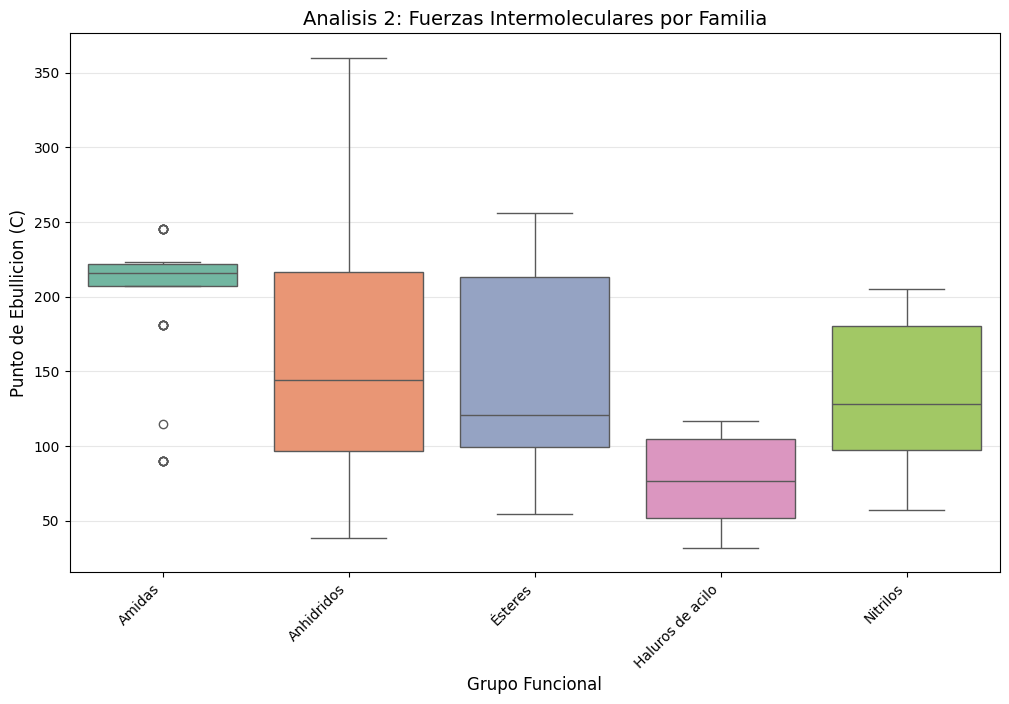

Estadisticas por grupo funcional:
  Amidas: Mediana=216C, n=60
  Anhidridos: Mediana=144C, n=20
  Ésteres: Mediana=121C, n=60
  Haluros de acilo: Mediana=77C, n=60
  Nitrilos: Mediana=128C, n=40
Conclusion: Las Amidas tienen mayor PE porque forman puentes de hidrogeno


In [32]:
plot_df = df.dropna(subset=['Grupo Funcional', 'PE_Sustrato °C'])
plot_df = plot_df[(plot_df['PE_Sustrato °C'] >= 20) & (plot_df['PE_Sustrato °C'] <= 400)]
plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]

# Solo grupos con al menos 3 compuestos
grupos_validos = plot_df['Grupo Funcional'].value_counts()
grupos_validos = grupos_validos[grupos_validos >= 3].index
plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

if len(plot_df) >= 5:
    # MODIFICABLE: figsize = (ancho, alto)
    plt.figure(figsize=(12, 7))

    # MODIFICABLE: palette='Set2' → 'viridis', 'pastel', 'dark', 'Set1', 'coolwarm'
    sns.boxplot(x='Grupo Funcional', y='PE_Sustrato °C', data=plot_df, palette='Set2')

    # MODIFICABLE: rotation=45 → 90 (vertical), 0 (horizontal)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('Punto de Ebullicion (C)', fontsize=12)
    plt.title('Analisis 2: Fuerzas Intermoleculares por Familia', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

    print("Estadisticas por grupo funcional:")
    for grupo in plot_df['Grupo Funcional'].unique():
        datos = plot_df[plot_df['Grupo Funcional']==grupo]['PE_Sustrato °C']
        print(f"  {grupo}: Mediana={datos.median():.0f}C, n={len(datos)}")
    print("Conclusion: Las Amidas tienen mayor PE porque forman puentes de hidrogeno")
else:
    print(f"Datos insuficientes para Analisis 2: {len(plot_df)} compuestos")

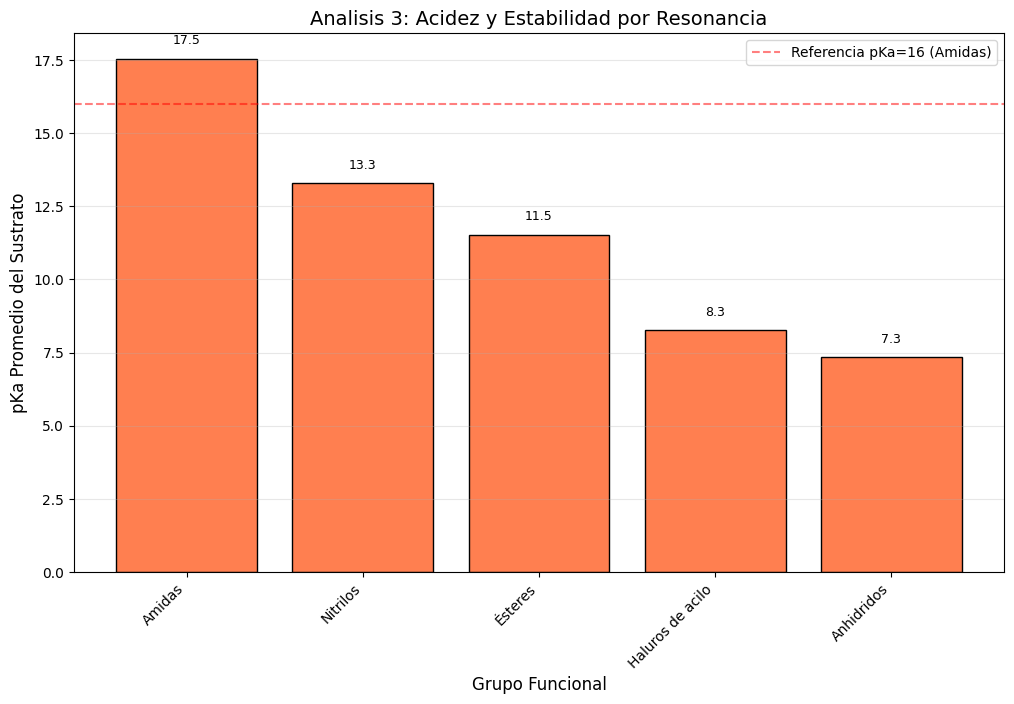

pKa promedio por grupo funcional:
  Amidas: pKa = 17.5
  Nitrilos: pKa = 13.3
  Ésteres: pKa = 11.5
  Haluros de acilo: pKa = 8.3
  Anhidridos: pKa = 7.3
Conclusion: Las Amidas tienen alto pKa por deslocalizacion del N en el C=O


In [33]:
plot_df = df.dropna(subset=['Grupo Funcional', 'pKa_Sustrato'])
plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] <= 50)]
plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]

grupos_validos = plot_df['Grupo Funcional'].value_counts()
grupos_validos = grupos_validos[grupos_validos >= 2].index
plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    # MODIFICABLE: sort_values(ascending=False) → ascending=True para orden inverso
    medias = plot_df.groupby('Grupo Funcional')['pKa_Sustrato'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 7))

    # MODIFICABLE: color='coral' → 'skyblue', 'purple', 'darkgreen', '#FF5733'
    plt.bar(range(len(medias)), medias.values, color='coral', edgecolor='black')
    plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('pKa Promedio del Sustrato', fontsize=12)
    plt.title('Analisis 3: Acidez y Estabilidad por Resonancia', fontsize=14)

    # MODIFICABLE: y=16 (valor de referencia), color, estilo
    plt.axhline(y=16, color='red', linestyle='--', alpha=0.5, label='Referencia pKa=16 (Amidas)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Anadir valores numericos sobre las barras
    for i, v in enumerate(medias.values):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)
    plt.show()

    print("pKa promedio por grupo funcional:")
    for grupo in medias.index:
        print(f"  {grupo}: pKa = {medias[grupo]:.1f}")
    print("Conclusion: Las Amidas tienen alto pKa por deslocalizacion del N en el C=O")
else:
    print(f"Datos insuficientes para Analisis 3: {len(plot_df)} compuestos")

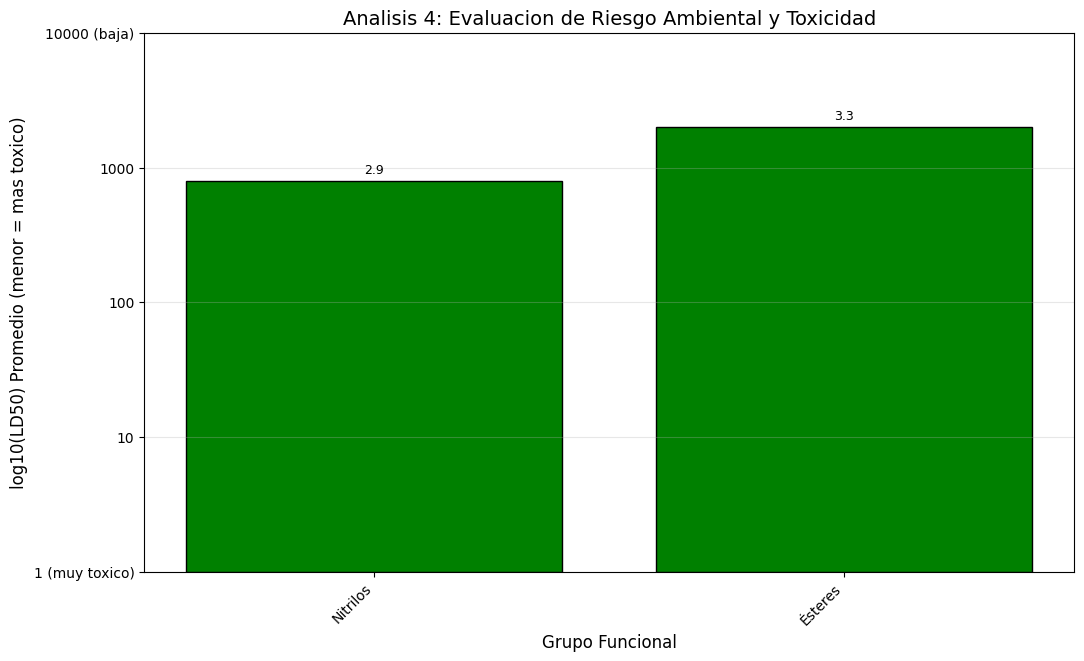

Clasificacion de riesgo:
  Nitrilos: LD50 ≈ 800.0 mg/kg -> BAJA TOXICIDAD
  Ésteres: LD50 ≈ 2014.2 mg/kg -> BAJA TOXICIDAD


In [34]:
plot_df = df.dropna(subset=['Grupo Funcional', 'LD50_Sustrato mg /kg'])
plot_df = plot_df[(plot_df['LD50_Sustrato mg /kg'] > 0.0001) & (plot_df['LD50_Sustrato mg /kg'] <= 5000)]
plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]
plot_df['log_LD50'] = np.log10(plot_df['LD50_Sustrato mg /kg'])

grupos_validos = plot_df['Grupo Funcional'].value_counts()
grupos_validos = grupos_validos[grupos_validos >= 2].index
plot_df = plot_df[plot_df['Grupo Funcional'].isin(grupos_validos)]

if len(plot_df) >= 4:
    medias = plot_df.groupby('Grupo Funcional')['log_LD50'].mean().sort_values()

    plt.figure(figsize=(12, 7))

    # MODIFICABLE: Umbrales de toxicidad (1.7 = LD50=50, 2.7 = LD50=500)
    colors = ['darkred' if v < 1.7 else 'orange' if v < 2.7 else 'green' for v in medias.values]
    plt.bar(range(len(medias)), medias.values, color=colors, edgecolor='black')
    plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
    plt.xlabel('Grupo Funcional', fontsize=12)
    plt.ylabel('log10(LD50) Promedio (menor = mas toxico)', fontsize=12)
    plt.title('Analisis 4: Evaluacion de Riesgo Ambiental y Toxicidad', fontsize=14)

    # MODIFICABLE: Etiquetas del eje Y (valores reales de LD50)
    plt.yticks([0, 1, 2, 3, 4], ['1 (muy toxico)', '10', '100', '1000', '10000 (baja)'])
    plt.grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(medias.values):
        plt.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9)
    plt.show()

    print("Clasificacion de riesgo:")
    for grupo in medias.index:
        media_log = medias[grupo]
        ld50_aprox = 10**media_log
        # MODIFICABLE: Umbrales de clasificacion (50 y 500 mg/kg)
        if ld50_aprox < 50:
            riesgo = "EXTREMADAMENTE TOXICO"
        elif ld50_aprox < 500:
            riesgo = "TOXICO"
        else:
            riesgo = "BAJA TOXICIDAD"
        print(f"  {grupo}: LD50 ≈ {ld50_aprox:.1f} mg/kg -> {riesgo}")
else:
    print(f"Datos insuficientes para Analisis 4: {len(plot_df)} compuestos")

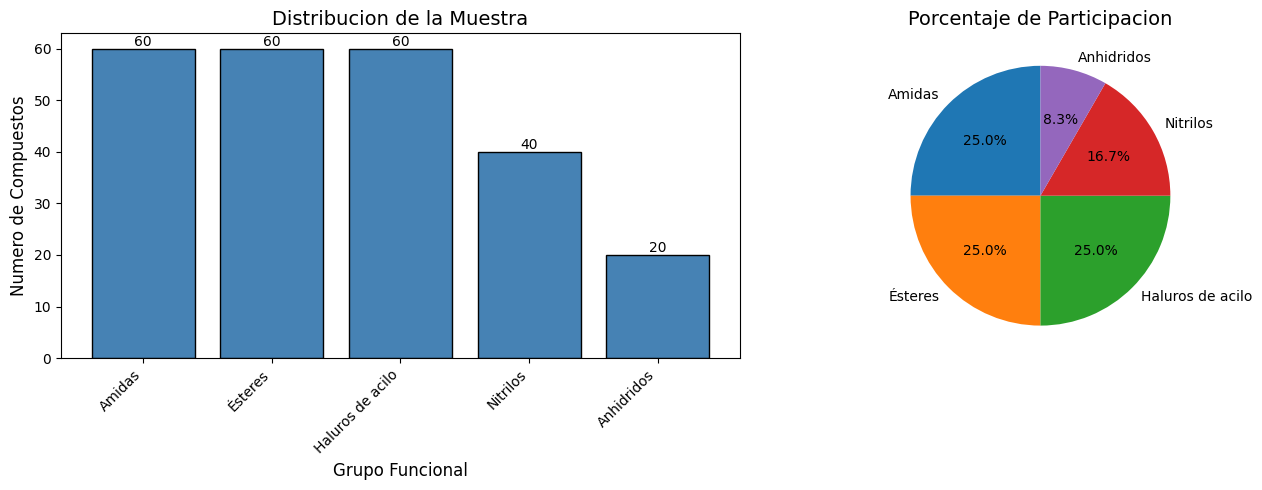

Total compuestos: 240
Grupo mas representado: Amidas (60 compuestos)


In [35]:
plot_df = df.dropna(subset=['Grupo Funcional'])
plot_df = plot_df[~plot_df['Grupo Funcional'].isin(['nan', 'None', ''])]
counts = plot_df['Grupo Funcional'].value_counts()

# MODIFICABLE: figsize = (ancho, alto) para los dos subgraficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras
# MODIFICABLE: color='steelblue' → cualquier color
ax1.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=45, ha='right')
ax1.set_xlabel('Grupo Funcional', fontsize=12)
ax1.set_ylabel('Numero de Compuestos', fontsize=12)
ax1.set_title('Distribucion de la Muestra', fontsize=14)
for i, v in enumerate(counts.values):
    ax1.text(i, v+0.5, str(v), ha='center')

# Grafico de torta (pie chart)
# MODIFICABLE: autopct='%1.1f%%' → '%1.0f%%' (sin decimales)
# MODIFICABLE: startangle=90 → 0 (derecha), 180 (abajo)
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Porcentaje de Participacion', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Total compuestos: {len(plot_df)}")
print(f"Grupo mas representado: {counts.index[0]} ({counts.iloc[0]} compuestos)")

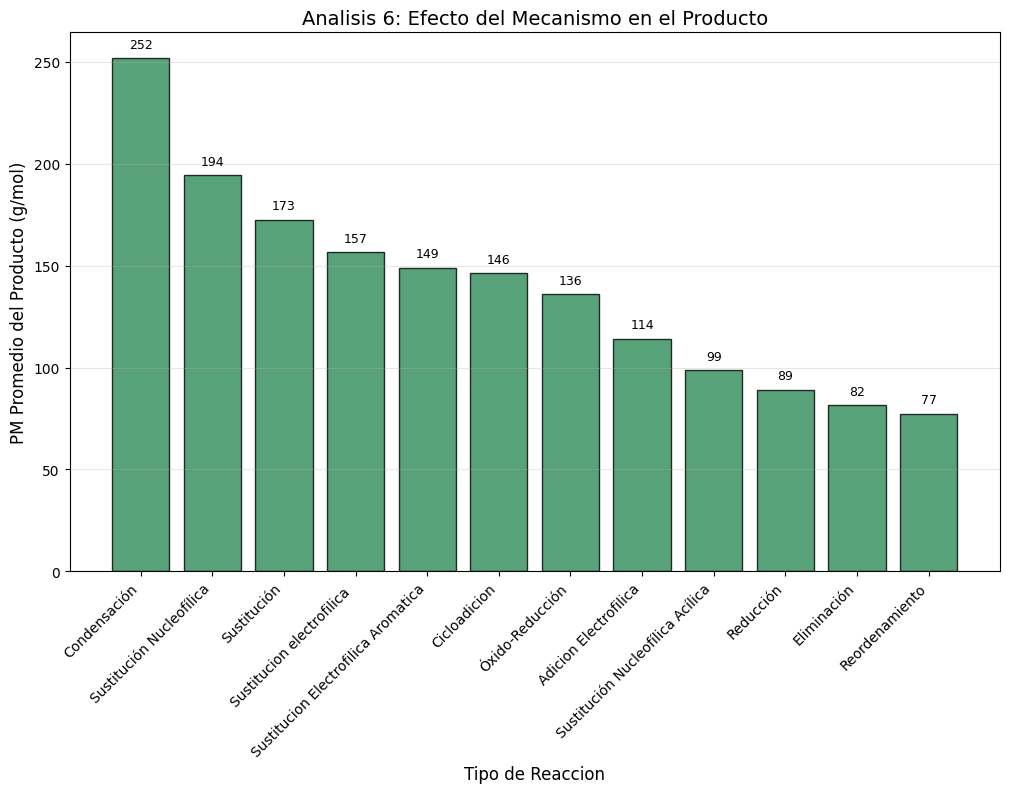

PM promedio por tipo de reaccion:
  Condensación: 252 g/mol
  Sustitución Nucleofílica: 194 g/mol
  Sustitución: 173 g/mol
  Sustitucion electrofilica : 157 g/mol
  Sustitucion Electrofilica Aromatica: 149 g/mol
  Cicloadicion: 146 g/mol
  Óxido-Reducción: 136 g/mol
  Adicion Electrofilica: 114 g/mol
  Sustitución Nucleofílica Acílica: 99 g/mol
  Reducción: 89 g/mol
  Eliminación: 82 g/mol
  Reordenamiento: 77 g/mol
Conclusion: Reduccion genera productos ligeros, Condensacion genera pesados


In [36]:
plot_df = df.dropna(subset=['Tipo_Reaccion', 'PM_Producto'])
plot_df = plot_df[(plot_df['PM_Producto'] > 0) & (plot_df['PM_Producto'] <= 600)]
plot_df = plot_df[~plot_df['Tipo_Reaccion'].isin(['nan', 'None', ''])]

tipos_validos = plot_df['Tipo_Reaccion'].value_counts()
tipos_validos = tipos_validos[tipos_validos >= 3].index
plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

if len(plot_df) >= 5:
    medias = plot_df.groupby('Tipo_Reaccion')['PM_Producto'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 7))

    # MODIFICABLE: color='seagreen', alpha=transparencia
    plt.bar(range(len(medias)), medias.values, color='seagreen', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(medias)), medias.index, rotation=45, ha='right')
    plt.xlabel('Tipo de Reaccion', fontsize=12)
    plt.ylabel('PM Promedio del Producto (g/mol)', fontsize=12)
    plt.title('Analisis 6: Efecto del Mecanismo en el Producto', fontsize=14)

    for i, v in enumerate(medias.values):
        plt.text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

    print("PM promedio por tipo de reaccion:")
    for tipo in medias.index:
        print(f"  {tipo}: {medias[tipo]:.0f} g/mol")
    print("Conclusion: Reduccion genera productos ligeros, Condensacion genera pesados")
else:
    print(f"Datos insuficientes para Analisis 6: {len(plot_df)} reacciones")

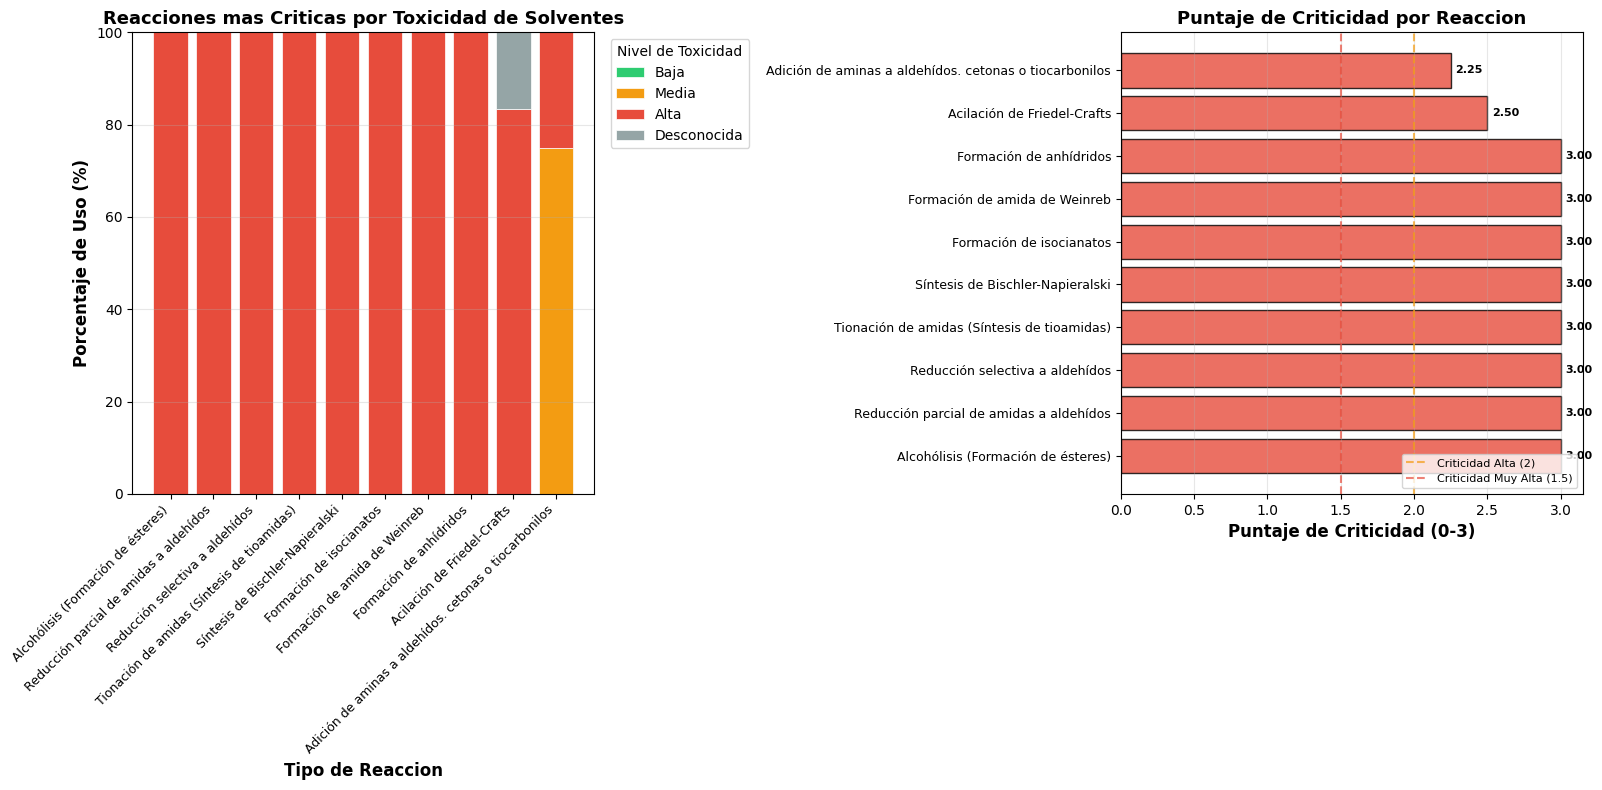

In [37]:
# MODIFICABLE: Anadir o quitar solventes de estas listas
solventes_alta_toxicidad = [
    'benceno', 'c6h6', 'tolueno', 'c7h8', 'xileno', 'c8h10',
    'cloroformo', 'chcl3', 'diclorometano', 'ch2cl2', 'cloruro de metileno',
    'clorobenceno', '1.2-dicloroetano', 'c2h4cl2'
]

solventes_media_toxicidad = [
    'eter', 'eter dietilico', 'c4h10o', 'thf', 'tetrahidrofurano', 'c4h8o', 'dioxano',
    'acetona', 'c3h6o', 'acetonitrilo', 'ch3cn', 'dmf', 'dimetilformamida', 'c3h7no',
    'hexano', 'c6h14', 'ciclohexano', 'c6h12'
]

solventes_baja_toxicidad = [
    'agua', 'h2o', 'etanol', 'c2h6o', 'etoh', 'metanol', 'ch3oh', 'meoh', 'isopropanol'
]

def clasificar_toxicidad_solvente(solvente):
    s = str(solvente).lower().strip()
    if s in solventes_baja_toxicidad:
        return 'Baja'
    elif s in solventes_media_toxicidad:
        return 'Media'
    elif s in solventes_alta_toxicidad:
        return 'Alta'
    else:
        return 'Desconocida'

plot_df = df.dropna(subset=['Nombre_Reaccion', 'Nombre_Solvente 1']).copy()
plot_df = plot_df[~plot_df['Nombre_Solvente 1'].astype(str).str.contains('nan|None|0', na=False, case=False)]
plot_df = plot_df[plot_df['Nombre_Solvente 1'].astype(str).str.strip() != '']
plot_df['Toxicidad_Solvente'] = plot_df['Nombre_Solvente 1'].apply(clasificar_toxicidad_solvente)

# Calcular porcentajes de toxicidad por reaccion
toxicidad_por_reaccion = plot_df.groupby('Nombre_Reaccion')['Toxicidad_Solvente'].value_counts(normalize=True).unstack(fill_value=0) * 100

for nivel in ['Baja', 'Media', 'Alta', 'Desconocida']:
    if nivel not in toxicidad_por_reaccion.columns:
        toxicidad_por_reaccion[nivel] = 0

# MODIFICABLE: Ponderaciones (Alta=3, Media=2, Baja=1)
toxicidad_por_reaccion['Puntaje_Criticidad'] = (
    toxicidad_por_reaccion['Alta'] * 3 +
    toxicidad_por_reaccion['Media'] * 2 +
    toxicidad_por_reaccion['Baja'] * 1
) / 100

toxicidad_por_reaccion = toxicidad_por_reaccion.sort_values('Puntaje_Criticidad', ascending=False)
conteo_reacciones = plot_df['Nombre_Reaccion'].value_counts()
reacciones_validas = conteo_reacciones[conteo_reacciones >= 2].index
toxicidad_por_reaccion = toxicidad_por_reaccion[toxicidad_por_reaccion.index.isin(reacciones_validas)]

# MODIFICABLE: Colores de los niveles de toxicidad
colores_toxicidad = {'Baja': '#2ecc71', 'Media': '#f39c12', 'Alta': '#e74c3c', 'Desconocida': '#95a5a6'}

top_criticas = toxicidad_por_reaccion.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Grafico 1: Barras apiladas
bottom = np.zeros(len(top_criticas))
for nivel, color in colores_toxicidad.items():
    if nivel in top_criticas.columns:
        valores = top_criticas[nivel].values
        ax1.bar(range(len(top_criticas)), valores, bottom=bottom, color=color,
                edgecolor='white', linewidth=0.5, label=nivel)
        bottom += valores

ax1.set_xticks(range(len(top_criticas)))
ax1.set_xticklabels(top_criticas.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Porcentaje de Uso (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipo de Reaccion', fontsize=12, fontweight='bold')
ax1.set_title('Reacciones mas Criticas por Toxicidad de Solventes', fontsize=13, fontweight='bold')
ax1.legend(title='Nivel de Toxicidad', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y')

# Grafico 2: Puntaje de criticidad (barras horizontales)
puntajes = top_criticas['Puntaje_Criticidad'].values

# MODIFICABLE: Umbrales de color: rojo > 2, amarillo > 1.5, verde el resto
colores_criticos = ['#e74c3c' if p > 2 else '#f39c12' if p > 1.5 else '#2ecc71' for p in puntajes]

bars = ax2.barh(range(len(top_criticas)), puntajes, color=colores_criticos, edgecolor='black', alpha=0.8)
ax2.set_yticks(range(len(top_criticas)))
ax2.set_yticklabels(top_criticas.index, fontsize=9)
ax2.set_xlabel('Puntaje de Criticidad (0-3)', fontsize=12, fontweight='bold')
ax2.set_title('Puntaje de Criticidad por Reaccion', fontsize=13, fontweight='bold')
ax2.axvline(x=2, color='#f39c12', linestyle='--', alpha=0.7, label='Criticidad Alta (2)')
ax2.axvline(x=1.5, color='#e74c3c', linestyle='--', alpha=0.7, label='Criticidad Muy Alta (1.5)')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='x')

for i, (bar, puntaje) in enumerate(zip(bars, puntajes)):
    ax2.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
             f'{puntaje:.2f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_843/1477759325.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['Tipo_Solvente'] = plot_df['Nombre_Solvente 1'].apply(clasificar_solvente)


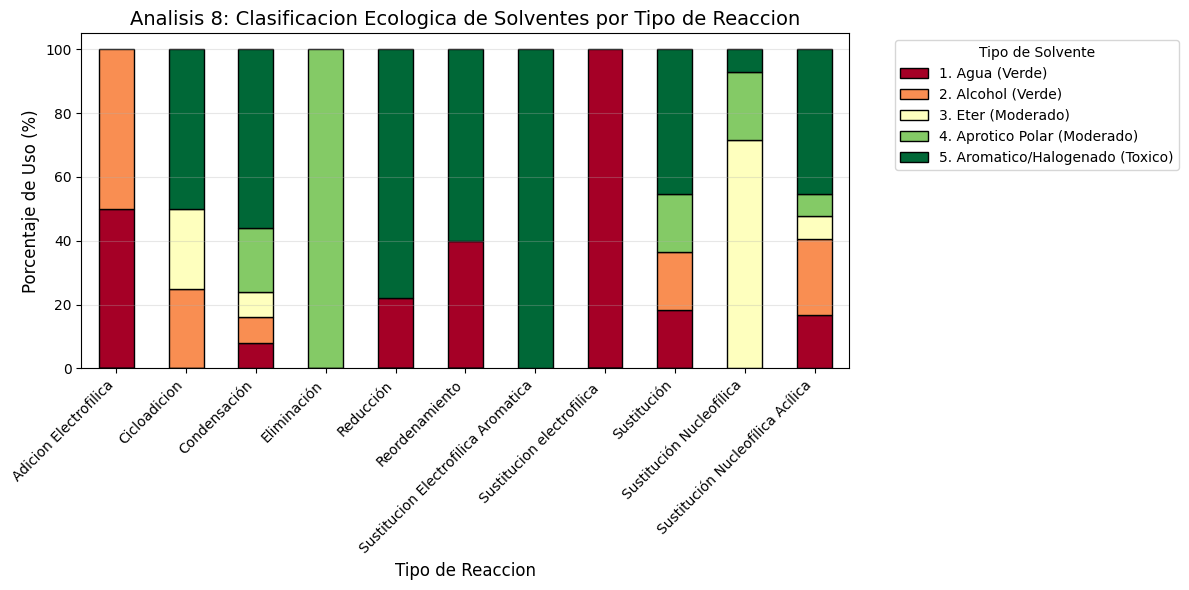

In [38]:
def clasificar_solvente(solvente):
    solvente = str(solvente).lower().strip()
    # MODIFICABLE: Anadir o modificar categorias
    if solvente in ['agua', 'h2o']:
        return '1. Agua (Verde)'
    elif solvente in ['etanol', 'c2h6o', 'etoh', 'metanol', 'ch3oh', 'meoh', 'isopropanol']:
        return '2. Alcohol (Verde)'
    elif solvente in ['eter', 'eter dietilico', 'c4h10o', 'thf', 'tetrahidrofurano', 'c4h8o']:
        return '3. Eter (Moderado)'
    elif solvente in ['acetona', 'c3h6o', 'acetonitrilo', 'ch3cn', 'dmf', 'dimetilformamida']:
        return '4. Aprotico Polar (Moderado)'
    elif solvente in ['benceno', 'c6h6', 'tolueno', 'c7h8', 'xileno', 'c8h10', 'cloroformo', 'chcl3', 'diclorometano', 'ch2cl2']:
        return '5. Aromatico/Halogenado (Toxico)'
    else:
        return '6. Otros'

plot_df = df.dropna(subset=['Tipo_Reaccion', 'Nombre_Solvente 1'])
plot_df['Tipo_Solvente'] = plot_df['Nombre_Solvente 1'].apply(clasificar_solvente)
plot_df = plot_df[~plot_df['Tipo_Solvente'].isin(['6. Otros'])]

tipos_validos = plot_df['Tipo_Reaccion'].value_counts()
tipos_validos = tipos_validos[tipos_validos >= 3].index
plot_df = plot_df[plot_df['Tipo_Reaccion'].isin(tipos_validos)]

if len(plot_df) >= 5:
    cross_tab = pd.crosstab(plot_df['Tipo_Reaccion'], plot_df['Tipo_Solvente'], normalize='index')*100
    orden_columnas = ['1. Agua (Verde)', '2. Alcohol (Verde)', '3. Eter (Moderado)',
                      '4. Aprotico Polar (Moderado)', '5. Aromatico/Halogenado (Toxico)']
    cross_tab = cross_tab[[col for col in orden_columnas if col in cross_tab.columns]]

    # MODIFICABLE: colormap='RdYlGn' (rojo a verde) → 'viridis', 'coolwarm', 'Blues'
    cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlGn', edgecolor='black')
    plt.xlabel('Tipo de Reaccion', fontsize=12)
    plt.ylabel('Porcentaje de Uso (%)', fontsize=12)
    plt.title('Analisis 8: Clasificacion Ecologica de Solventes por Tipo de Reaccion', fontsize=14)
    plt.legend(title='Tipo de Solvente', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print(f"Datos insuficientes para Analisis 8: {len(plot_df)} reacciones")

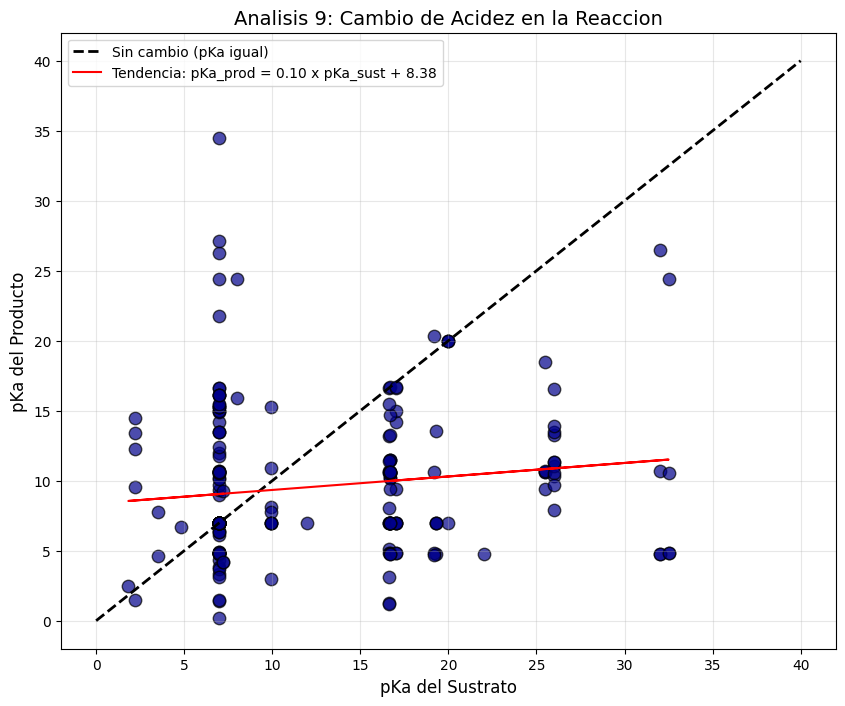

Cambio promedio de pKa: -2.72
Conclusion: Los productos son MAS acidos que los sustratos


In [40]:
plot_df = df.dropna(subset=['pKa_Sustrato', 'pKa_Producto'])
plot_df = plot_df[(plot_df['pKa_Sustrato'] > 0) & (plot_df['pKa_Sustrato'] <= 40)]
plot_df = plot_df[(plot_df['pKa_Producto'] > 0) & (plot_df['pKa_Producto'] <= 40)]
plot_df['Delta'] = plot_df['pKa_Producto'] - plot_df['pKa_Sustrato']

if len(plot_df) >= 3:
    plt.figure(figsize=(10, 8))

    # MODIFICABLE: color de puntos, tamano, transparencia
    plt.scatter(plot_df['pKa_Sustrato'], plot_df['pKa_Producto'],
                alpha=0.7, s=80, c='darkblue', edgecolors='black')

    # Linea de identidad (sin cambio)
    # MODIFICABLE: cambiar [0,40] si cambias los rangos
    plt.plot([0, 40], [0, 40], 'k--', linewidth=2, label='Sin cambio (pKa igual)')

    # Linea de tendencia (regresion lineal)
    if len(plot_df) >= 4:
        z = np.polyfit(plot_df['pKa_Sustrato'], plot_df['pKa_Producto'], 1)
        plt.plot(plot_df['pKa_Sustrato'], np.poly1d(z)(plot_df['pKa_Sustrato']), 'r-',
                 label=f'Tendencia: pKa_prod = {z[0]:.2f} x pKa_sust + {z[1]:.2f}')

    plt.xlabel('pKa del Sustrato', fontsize=12)
    plt.ylabel('pKa del Producto', fontsize=12)
    plt.title('Analisis 9: Cambio de Acidez en la Reaccion', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Cambio promedio de pKa: {plot_df['Delta'].mean():.2f}")
    if plot_df['Delta'].mean() > 0:
        print("Conclusion: Los productos son MENOS acidos que los sustratos")
    else:
        print("Conclusion: Los productos son MAS acidos que los sustratos")
else:
    print(f"Datos insuficientes para Analisis 9: {len(plot_df)} reacciones")

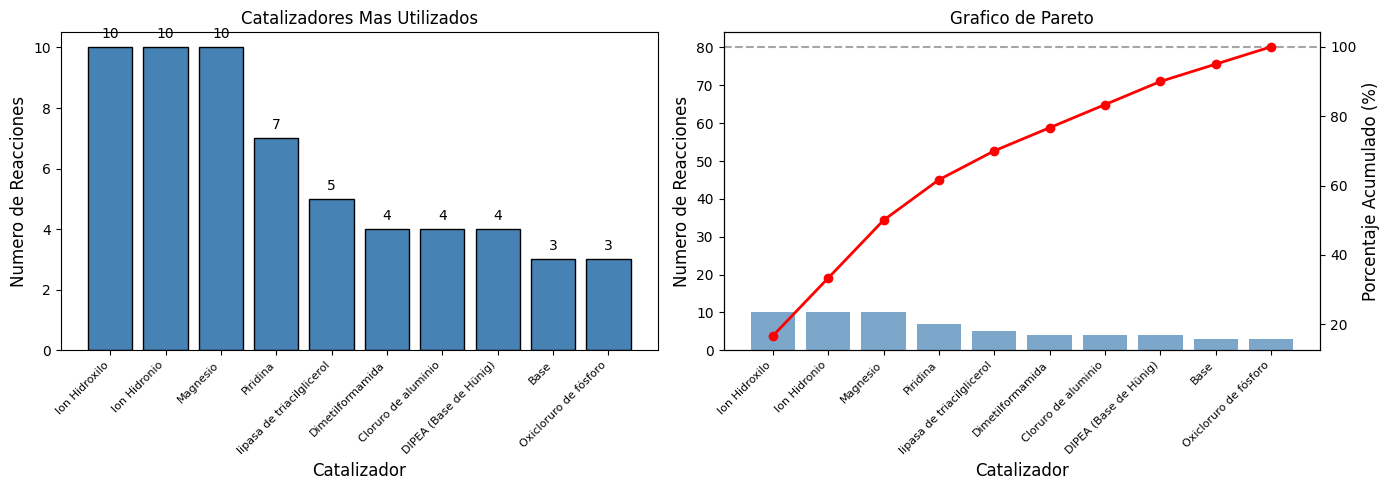

Catalizador mas usado: Ion Hidroxilo (10 reacciones)
Top 3 concentra el 29.7%


In [41]:
plot_df = df.dropna(subset=['Nombre_Catalizador 1'])
plot_df = plot_df[~plot_df['Nombre_Catalizador 1'].astype(str).str.contains('nan', na=False)]
plot_df['Catalizador'] = plot_df['Nombre_Catalizador 1'].str.split(';').str[0].str.strip()

# MODIFICABLE: head(10) → head(15) para ver mas catalizadores
counts = plot_df['Catalizador'].value_counts().head(10)

if len(counts) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Grafico de barras (izquierda)
    ax1.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
    ax1.set_xticks(range(len(counts)))
    ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax1.set_xlabel('Catalizador', fontsize=12)
    ax1.set_ylabel('Numero de Reacciones', fontsize=12)
    ax1.set_title('Catalizadores Mas Utilizados', fontsize=12)
    for i, v in enumerate(counts.values):
        ax1.text(i, v+0.3, str(v), ha='center')

    # Grafico de Pareto (derecha) - barras + linea acumulada
    porcentajes = counts.cumsum() / counts.sum() * 100
    ax2.bar(range(len(counts)), counts.values, color='steelblue', alpha=0.7)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(range(len(counts)), porcentajes, 'r-o', linewidth=2, markersize=6)
    ax2_twin.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax2.set_xticks(range(len(counts)))
    ax2.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax2.set_xlabel('Catalizador', fontsize=12)
    ax2.set_ylabel('Numero de Reacciones', fontsize=12)
    ax2.set_title('Grafico de Pareto', fontsize=12)

    # MODIFICABLE: linea del 80% (principio de Pareto)
    ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% Pareto')

    plt.tight_layout()
    plt.show()

    print(f"Catalizador mas usado: {counts.index[0]} ({counts.iloc[0]} reacciones)")
    print(f"Top 3 concentra el {100*counts.head(3).sum()/len(plot_df):.1f}%")
else:
    print(f"Datos insuficientes para Analisis 10: {len(counts)} catalizadores")

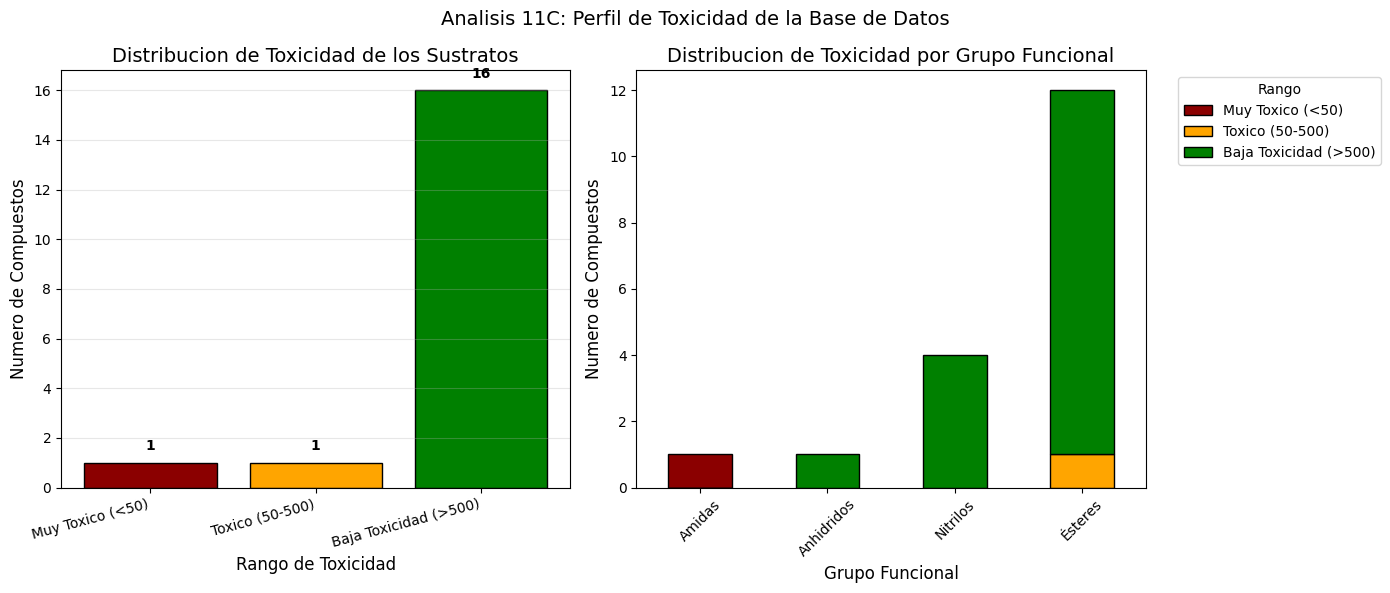

RESUMEN DE TOXICIDAD DE LA BASE DE DATOS

Total de compuestos con datos de LD50: 18

Distribucion por rango:
  Muy Toxico (<50): 1 compuestos (5.6%)
  Toxico (50-500): 1 compuestos (5.6%)
  Baja Toxicidad (>500): 16 compuestos (88.9%)

Grupos funcionales mas peligrosos:
  ! Amidas: 1 compuestos extremadamente toxicos

CONCLUSION
! Se identificaron 1 compuestos EXTREMADAMENTE TOXICOS
   -> Requieren protocolos de seguridad especiales


In [42]:
plot_df = df.dropna(subset=['LD50_Sustrato mg /kg'])
plot_df = plot_df[(plot_df['LD50_Sustrato mg /kg'] > 0.0001) & (plot_df['LD50_Sustrato mg /kg'] <= 5000)]

# MODIFICABLE: Umbrales de clasificacion (50 y 500 mg/kg)
def clasificar_ld50(ld50):
    if ld50 < 50:
        return 'Muy Toxico (<50)'
    elif ld50 < 500:
        return 'Toxico (50-500)'
    else:
        return 'Baja Toxicidad (>500)'

plot_df['Rango_Toxicidad'] = plot_df['LD50_Sustrato mg /kg'].apply(clasificar_ld50)

# Contar por rango
conteo_rangos = plot_df['Rango_Toxicidad'].value_counts()
conteo_rangos = conteo_rangos.reindex(['Muy Toxico (<50)', 'Toxico (50-500)', 'Baja Toxicidad (>500)'])

# MODIFICABLE: Colores de los rangos
colores_rangos = {'Muy Toxico (<50)': 'darkred', 'Toxico (50-500)': 'orange', 'Baja Toxicidad (>500)': 'green'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Barras por rango de toxicidad
colores_barra = [colores_rangos[r] for r in conteo_rangos.index if r in colores_rangos]
ax1.bar(range(len(conteo_rangos)), conteo_rangos.values, color=colores_barra, edgecolor='black')
ax1.set_xticks(range(len(conteo_rangos)))
ax1.set_xticklabels(conteo_rangos.index, rotation=15, ha='right')
ax1.set_xlabel('Rango de Toxicidad', fontsize=12)
ax1.set_ylabel('Numero de Compuestos', fontsize=12)
ax1.set_title('Distribucion de Toxicidad de los Sustratos', fontsize=14)
for i, v in enumerate(conteo_rangos.values):
    ax1.text(i, v+0.5, str(v), ha='center', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Grafico 2: Proporcion por grupo funcional (barras apiladas)
plot_df_grupo = plot_df.groupby(['Grupo Funcional', 'Rango_Toxicidad']).size().unstack(fill_value=0)
plot_df_grupo = plot_df_grupo[['Muy Toxico (<50)', 'Toxico (50-500)', 'Baja Toxicidad (>500)']]
plot_df_grupo = plot_df_grupo[plot_df_grupo.sum(axis=1) > 0]  # Solo grupos con datos

plot_df_grupo.plot(kind='bar', stacked=True, ax=ax2, color=colores_rangos, edgecolor='black')
ax2.set_xlabel('Grupo Funcional', fontsize=12)
ax2.set_ylabel('Numero de Compuestos', fontsize=12)
ax2.set_title('Distribucion de Toxicidad por Grupo Funcional', fontsize=14)
ax2.legend(title='Rango', bbox_to_anchor=(1.05, 1))
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Analisis 11C: Perfil de Toxicidad de la Base de Datos', fontsize=14)
plt.tight_layout()
plt.show()

print("=" * 60)
print("RESUMEN DE TOXICIDAD DE LA BASE DE DATOS")
print("=" * 60)
print(f"\nTotal de compuestos con datos de LD50: {len(plot_df)}")
print(f"\nDistribucion por rango:")
for rango in ['Muy Toxico (<50)', 'Toxico (50-500)', 'Baja Toxicidad (>500)']:
    count = conteo_rangos.get(rango, 0)
    pct = 100 * count / len(plot_df) if len(plot_df) > 0 else 0
    print(f"  {rango}: {count} compuestos ({pct:.1f}%)")

print(f"\nGrupos funcionales mas peligrosos:")
for grupo in plot_df_grupo.index:
    muy_toxico = plot_df_grupo.loc[grupo, 'Muy Toxico (<50)'] if 'Muy Toxico (<50)' in plot_df_grupo.columns else 0
    if muy_toxico > 0:
        print(f"  ! {grupo}: {muy_toxico} compuestos extremadamente toxicos")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
muy_toxico_total = conteo_rangos.get('Muy Toxico (<50)', 0)
if muy_toxico_total > 0:
    print(f"! Se identificaron {muy_toxico_total} compuestos EXTREMADAMENTE TOXICOS")
    print("   -> Requieren protocolos de seguridad especiales")
else:
    print(" La base de datos no contiene compuestos extremadamente toxicos")